## Program 4 Algorithims - Benchmarking Heaps
#### By: Viannys Colon, Madison Mina, and David Salzman
### Introduction
In this project we are implementing three versions of Heapify operation. Heapify operation takes an array in and outputs a heap. The output type is still an array but it is a heap version so children are found later in the array than the parents.
### Description
The first method is the typical built in heapify method - classic method: Add elements one at a time at the root of the tree and bubble them down the tree.

The second method bubbles down by children: Add element one at a time at the root of tree and bubbles down by stopping when element is greater than children.

The third method bubbles down then up: Add element one at a time at the root of tree bubble it all the way down. Then bubble up until element is smaller than its parent.

We will benchmark each method to see which version is the fastest at heapifying an array. The tests will be done with 3 different datasets as detailed in Approach Section.

### Approach
The benchmarking will be done using 3 different datasets.

- increasing - sorted array
- decreasing - reverse sorted
- random - shuffled

Each dataset will be sorted with each of the different methods. They will be compared using runtime of when a method completed the operation. In addition it may also be benefical to test with different size arrays (one small array, one medium array, one big array) to see how much the number of elements impact the efficency of the methods.

### Source Code & Function Explanations

In [22]:
def heapify_method1(arr):
    """Build a max-heap by inserting elements one at a time using sift-up.

    This method appends each element to an internal heap list and performs a
    sift-up (bubble-up) operation to restore the heap property after every
    insertion.

    Time complexity: O(n log n) in the worst case because each of the n
    insertions may require O(log n) swaps to move the element up the tree.
    Space: O(1) additional (returns a new list containing the heap).
    """
    h = []
    def sift_up(h, i):
        while i > 0:
            p = (i - 1) // 2
            if h[i] > h[p]:
                h[i], h[p] = h[p], h[i]
                i = p
            else:
                break
    for x in arr:
        h.append(x)
        sift_up(h, len(h) - 1)
    return h

In [23]:
def heapify_method2(arr):
    """Bottom-up (Floyd) heapify: transform the array into a max-heap in-place.

    This method starts from the last non-leaf node and sifts each node down
    (bubble-down by children) to restore the heap property. It operates on a copy
    of the input and runs in linear time on average.

    Time complexity: O(n).
    Space: O(1) additional (works in-place on a copy).
    """
    h = arr.copy()
    n = len(h)
    def sift_down(h, i, n):
        while True:
            left = 2 * i + 1
            right = left + 1
            largest = i
            if left < n and h[left] > h[largest]:
                largest = left
            if right < n and h[right] > h[largest]:
                largest = right
            if largest == i:
                break
            h[i], h[largest] = h[largest], h[i]
            i = largest
    for i in range((n // 2) - 1, -1, -1):
        sift_down(h, i, n)
    return h

In [24]:
def heapify_method3(arr):
    """Hybrid: insert each element at the root, bubble it down fully, then bubble up.

    For each new element we append it to the heap list and swap it into the root
    position. We then bubble it down (following larger children) until it reaches
    a leaf, and finally bubble it up as needed to fix any violation with its parent.

    This demonstrates the 'bubble down then up' strategy. It is generally less
    efficient than the bottom-up method and typically runs in O(n log n) worst case.

    Time complexity: O(n log n) worst-case.
    Space: O(1) additional (returns a new list).
    """
    h = []
    def sift_down_from(h, i):
        n = len(h)
        while True:
            left = 2 * i + 1
            right = left + 1
            largest = i
            if left < n and h[left] > h[largest]:
                largest = left
            if right < n and h[right] > h[largest]:
                largest = right
            if largest == i:
                break
            h[i], h[largest] = h[largest], h[i]
            i = largest
        return i
    def sift_up_from(h, i):
        while i > 0:
            p = (i - 1) // 2
            if h[i] > h[p]:
                h[i], h[p] = h[p], h[i]
                i = p
            else:
                break
    for x in arr:
        h.append(x)
        if len(h) > 1:
            # place new element at root, then bubble down and up
            h[0], h[-1] = h[-1], h[0]
            idx = sift_down_from(h, 0)
            sift_up_from(h, idx)
    return h

### Benchmark Parameters
The benchmarks were conducted using three types of input data: random arrays, sorted arrays, and reverse-sorted arrays. These help evaluate how input order affects the performance of different heap approaches/methods. Each dataset was generated for input sizes ranging from 1,000 to 50,000 elements, allowing us to observe how runtime scales as the problem size increases. To ensure reliable results, each experiment was repeated five times, and the average runtime was recorded. 

In [25]:
import os
import time
import random
import csv
import pandas as pd

SIZES = [1000, 2000, 5000, 10000, 20000, 50000]
TRIALS = 5
INPUT_TYPES = ['random', 'sorted', 'reversed']

METHODS = {
    "method1": heapify_method1,
    "method2": heapify_method2,
    "method3": heapify_method3,
}

In [26]:
def generate_input(n, input_type):
    if input_type == 'random':
        return random.sample(range(n), n)
    elif input_type == 'sorted':
        return list(range(n))
    elif input_type == 'reversed':
        return list(range(n, 0, -1))
    else:
        raise ValueError("Unknown input type")

In [27]:
def time_function(func, arr):
    start = time.perf_counter()
    func(arr.copy())  
    end = time.perf_counter()
    return end - start

In [ ]:
results = []

def run_benchmarks():
    for n in SIZES:
        for input_type in INPUT_TYPES:
            base_array = generate_input(n, input_type)
            
            for method_name, func in METHODS.items():
                if func is None:
                    continue
                
                for trial in range(TRIALS):
                    t = time_function(func, base_array)
                    
                    results.append({
                        "n": n,
                        "input": input_type,
                        "method": method_name,
                        "time": t
                    })

    return pd.DataFrame(results)

df = run_benchmarks()

,n,input,method,time
0,1000,random,method1,0.000983
1,1000,random,method1,0.000974
2,1000,random,method1,0.000723
3,1000,random,method1,0.000792
4,1000,random,method1,0.000822
...,...,...,...,...
265,50000,reversed,method3,0.278880
266,50000,reversed,method3,0.287314
267,50000,reversed,method3,0.277221
268,50000,reversed,method3,0.272714


### Results: Tables and Graphs
- A table and graph for each *function* showing results for each case (input type).
- A table and graph for each *case* showing the results for each function.

Suggested layout: For each method, show a CSV/aggregated table (mean/std) and a log-log plot of time vs n per input type. For each input type, show a log-log plot of time vs n per method.

In [30]:
for method in df["method"].unique():
    display(df[df["method"] == method])

,n,input,method,time
0,1000,random,method1,0.000983
1,1000,random,method1,0.000974
2,1000,random,method1,0.000723
3,1000,random,method1,0.000792
4,1000,random,method1,0.000822
...,...,...,...,...
255,50000,reversed,method1,0.017099
256,50000,reversed,method1,0.015641
257,50000,reversed,method1,0.017818
258,50000,reversed,method1,0.018172


,n,input,method,time
5,1000,random,method2,0.000668
6,1000,random,method2,0.000518
7,1000,random,method2,0.000466
8,1000,random,method2,0.000431
9,1000,random,method2,0.000431
...,...,...,...,...
260,50000,reversed,method2,0.010975
261,50000,reversed,method2,0.010113
262,50000,reversed,method2,0.012163
263,50000,reversed,method2,0.010911


,n,input,method,time
10,1000,random,method3,0.001302
11,1000,random,method3,0.001219
12,1000,random,method3,0.001268
13,1000,random,method3,0.001440
14,1000,random,method3,0.001215
...,...,...,...,...
265,50000,reversed,method3,0.278880
266,50000,reversed,method3,0.287314
267,50000,reversed,method3,0.277221
268,50000,reversed,method3,0.272714


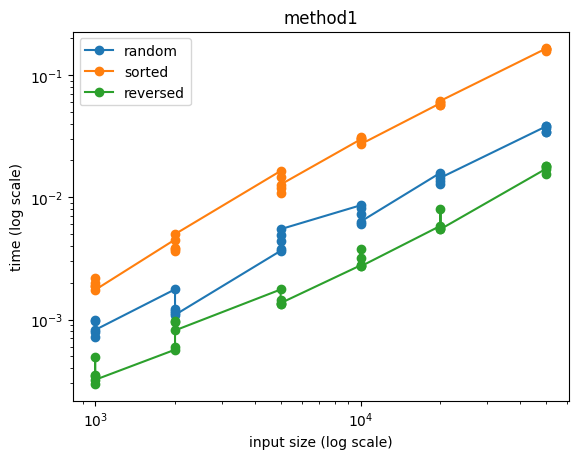

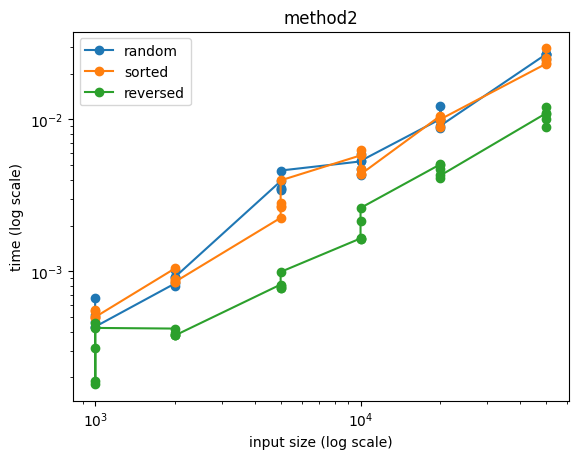

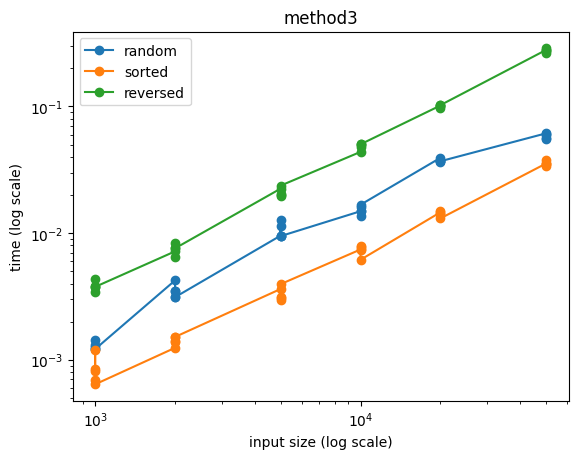

In [36]:
import matplotlib.pyplot as plt

for method in df["method"].unique():
    plt.figure()
    
    subset = df[df["method"] == method]
    
    for input_type in INPUT_TYPES:
        data = subset[subset["input"] == input_type]
        
        plt.plot(
            data["n"],
            data["time"],
            marker="o",
            label=input_type
        )
    
    plt.xscale("log")
    plt.yscale("log")
    plt.title(f"{method}")
    plt.xlabel("input size (log scale)")
    plt.ylabel("time (log scale)")
    plt.legend()
    plt.show()

### Regression Analysis
TODO: An analysis using the regression techniques from the second homework to estimate the asymptotic time complexity
for each best(but crossed out) case.

### Summary of Findings
TODO: 1-2 paragraphs of text summarizing all interesting results.

### Questions & Answers
Answer the following using your experimental evidence.

- **For each approach:**
1. Does the empirically-determined runtime match the theoretic runtime? If not, what might have caused the discrepancy?
2. Was there a noticeable difference between sorted, reverse-sorted, and random data? If so, describe and explain.

- What runtime effect do you get by using heapify vs adding all elements to an empty heap? Explain.
- Compare bubbling down and stopping short to bubbling all the way down, then back up. When might each approach be better?

### Appendix: Source Code & Test Cases
TODO